# Importación de librearías y semilla

In [ ]:
import numpy as np # trabaja con matrices y operaciones matemáticas
import matplotlib.pyplot as plt # muestra imágenes y gráficas
from matplotlib.image import imread # leer imágenes
np.random.seed(42) # aleatoriedad para que siempre salga el mismo ruido
# y no cambie cada que corremos el código

# Cargar imagen

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CHEST XRAY.png to CHEST XRAY.png


In [ ]:
ruta_imagen = "CHEST XRAY.png"
imagen_cargada = imread(ruta_imagen)
imagen_cargada = imagen_cargada.astype(np.float32)
if imagen_cargada.max() > 1.0: # si la imagen viene de 0-255 la
                                #convertimos de rango 0-1
    imagen_cargada = imagen_cargada / 255.0
print("Dimensiones:", imagen_cargada.shape)
print("Valor mínimo:", imagen_cargada.min())
print("Valor máximo:", imagen_cargada.max())

Dimensiones: (1024, 1024)
Valor mínimo: 0.0
Valor máximo: 0.9411765


# Mostrar imagen original


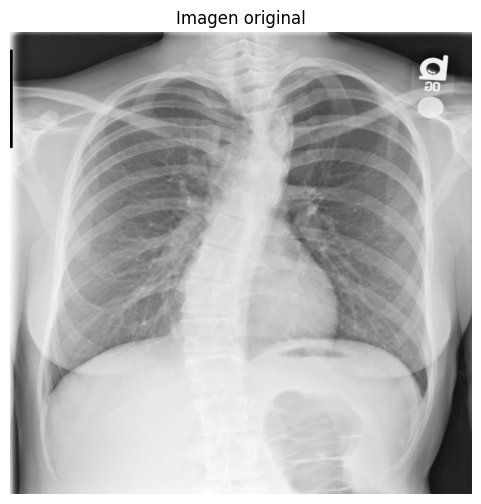

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(imagen_cargada, cmap = 'gray')
plt.title("Imagen original")
plt.axis('off')
plt.show()

# Convertir a escala de grises

In [ ]:
if len(imagen_cargada.shape) == 3:
    imagen_gris = (
        0.2989 * imagen_cargada[:, :, 0] +
        0.5870 * imagen_cargada[:, :, 1] +
        0.1140 * imagen_cargada[:, :, 2]
    )
else:
    imagen_gris = imagen_cargada

# Función para limitar valores

In [ ]:
def limitar_valores(imagen):
  return np.clip(imagen, 0.0, 1.0)

# Ruido Gaussiano

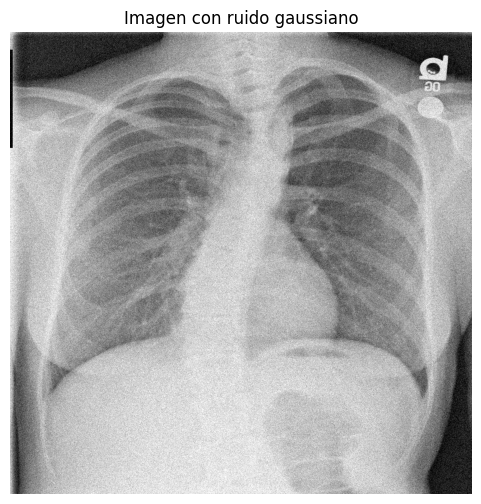

In [ ]:
# el ruido es tipo "granulado" en toda la imagen. cada pixel
# recibe una pequeña alteración aleatoria.
# en radiografías esto puede simular ruido electrónico del sensor
# o variaciones aleatorias durante la adquisición digital

def ruido_gaussiano(imagen, media = 0.0, desviacion = 0.08):
  ruido = np.random.normal(
      loc = media,
      scale = desviacion,
      size = imagen.shape
  )

  imagen_con_ruido = imagen + ruido
  imagen_con_ruido = limitar_valores(imagen_con_ruido)
  return imagen_con_ruido

imagen_gaussiana = ruido_gaussiano(imagen_gris)

plt.figure(figsize=(6,6))
plt.imshow(imagen_gaussiana, cmap = 'gray')
plt.title("Imagen con ruido gaussiano")
plt.axis('off')
plt.show()

# Ruido Salt and Pepper

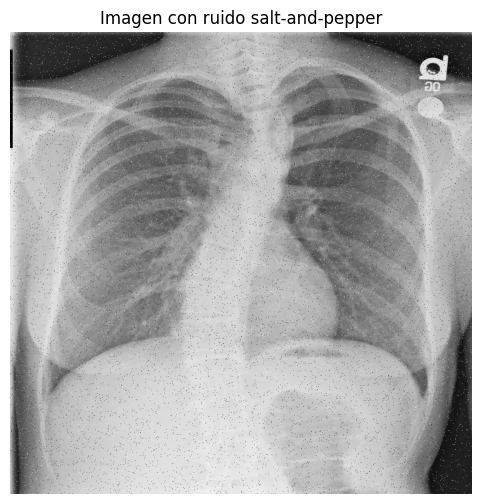

In [ ]:
# Este ruido pone puntos negros y blancos al azar, por eso el nombre
# En radiografías puede tapar detalles pequeños o confundirse con
# estructuras puntuales
def ruido_sal_pimienta(imagen, probabilidad=0.02):

    imagen_con_ruido = imagen.copy()

    matriz_aleatoria = np.random.random(imagen.shape)

    imagen_con_ruido[matriz_aleatoria < probabilidad / 2] = 0.0

    imagen_con_ruido[matriz_aleatoria > 1 - probabilidad / 2] = 1.0

    return imagen_con_ruido


# Aplicar ruido
imagen_sal_pimienta = ruido_sal_pimienta(imagen_gris)

# Mostrar imagen
plt.figure(figsize=(6,6))

plt.imshow(imagen_sal_pimienta, cmap='gray')

plt.title("Imagen con ruido salt-and-pepper")

plt.axis('off')

plt.show()

# Ruido Speckle

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

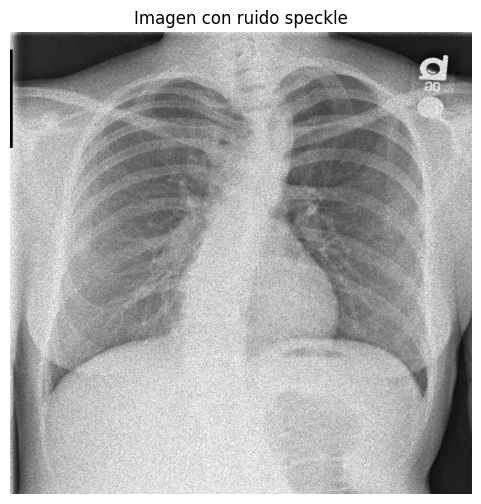

In [ ]:
# Es ruido multiplicativo, no solo se suma encima de la imagen sino
# que depende de la intensidad original de cada pixel.
# Las zonas más claras pueden alterarse más que las zonas oscuras.

def ruido_speckle(imagen, desviacion = 0.15):
  ruido = np.random.normal(
      loc = 0.0,
      scale = desviacion,
      size = imagen.shape
  )

  imagen_con_ruido = imagen + imagen * ruido
  imagen_con_ruido = limitar_valores(imagen_con_ruido)
  return imagen_con_ruido

imagen_speckle = ruido_speckle(imagen_gris)
plt.figure(figsize=(6,6))
plt.imshow(imagen_speckle, cmap = 'gray')
plt.title("Imagen con ruido speckle")
plt.axis('off')

# Ruido Poisson

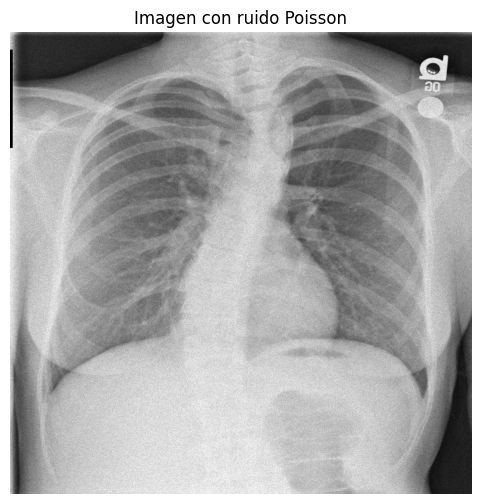

In [ ]:
# El ruido poisson se relaciona con conteo de señales o partículas
# como fotones o eventos detectados. En imágenes médicas
# sirve para representar variaciones producidas por la forma en
# que se adquiere la señal física.
def ruido_poisson(imagen):
  escala = 255
  imagen_escalada = imagen*escala
  imagen_con_ruido = np.random.poisson(imagen_escalada)
  imagen_con_ruido = imagen_con_ruido / escala
  imagen_con_ruido = limitar_valores(imagen_con_ruido)
  return imagen_con_ruido

imagen_poissonn = ruido_poisson(imagen_gris)

plt.figure(figsize=(6,6))
plt.imshow(imagen_poissonn, cmap = 'gray')
plt.title("Imagen con ruido Poisson")
plt.axis('off')
plt.show()

# Ruido tipo interferencia de pantalla

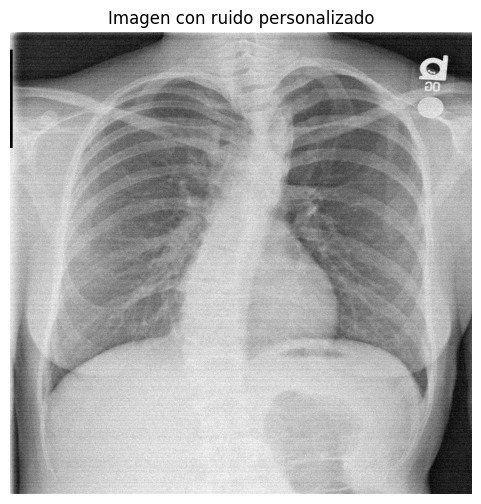

In [ ]:
# Ruido que combina granulado, líneas horizontales y variaciones
# de brillo por filas. Simula una interferencia de adquisición
# o visualización, parecida a una pantalla con fallas.
# En una radiografía podría dificultar la identificación de bordes
# anatómicos o zonas de bajo contraste.
def ruido_interferencia(imagen, desviacion = 0.05, intensidad_linea = 0.12):
  filas, columnas = imagen.shape

  ruido = np.random.normal(
    loc = 0.0,
    scale = desviacion,
    size = imagen.shape
  )

  lineas = np.zeros_like(imagen)
  for fila in range(0, filas, 8):
    lineas[fila:fila+2, :] = intensidad_linea
    variacion_filas = np.random.uniform(
        low=-0.03,
        high=0.03,
        size=(filas, 1)
    )

    imagen_con_ruido = imagen + ruido + lineas + variacion_filas

    imagen_con_ruido = limitar_valores(imagen_con_ruido)

    return imagen_con_ruido


imagen_interferencia = ruido_interferencia(imagen_gris)

plt.figure(figsize=(6,6))
plt.imshow(imagen_interferencia, cmap='gray')
plt.title("Imagen con ruido personalizado")
plt.axis('off')
plt.show()

# Comparación de imágenes

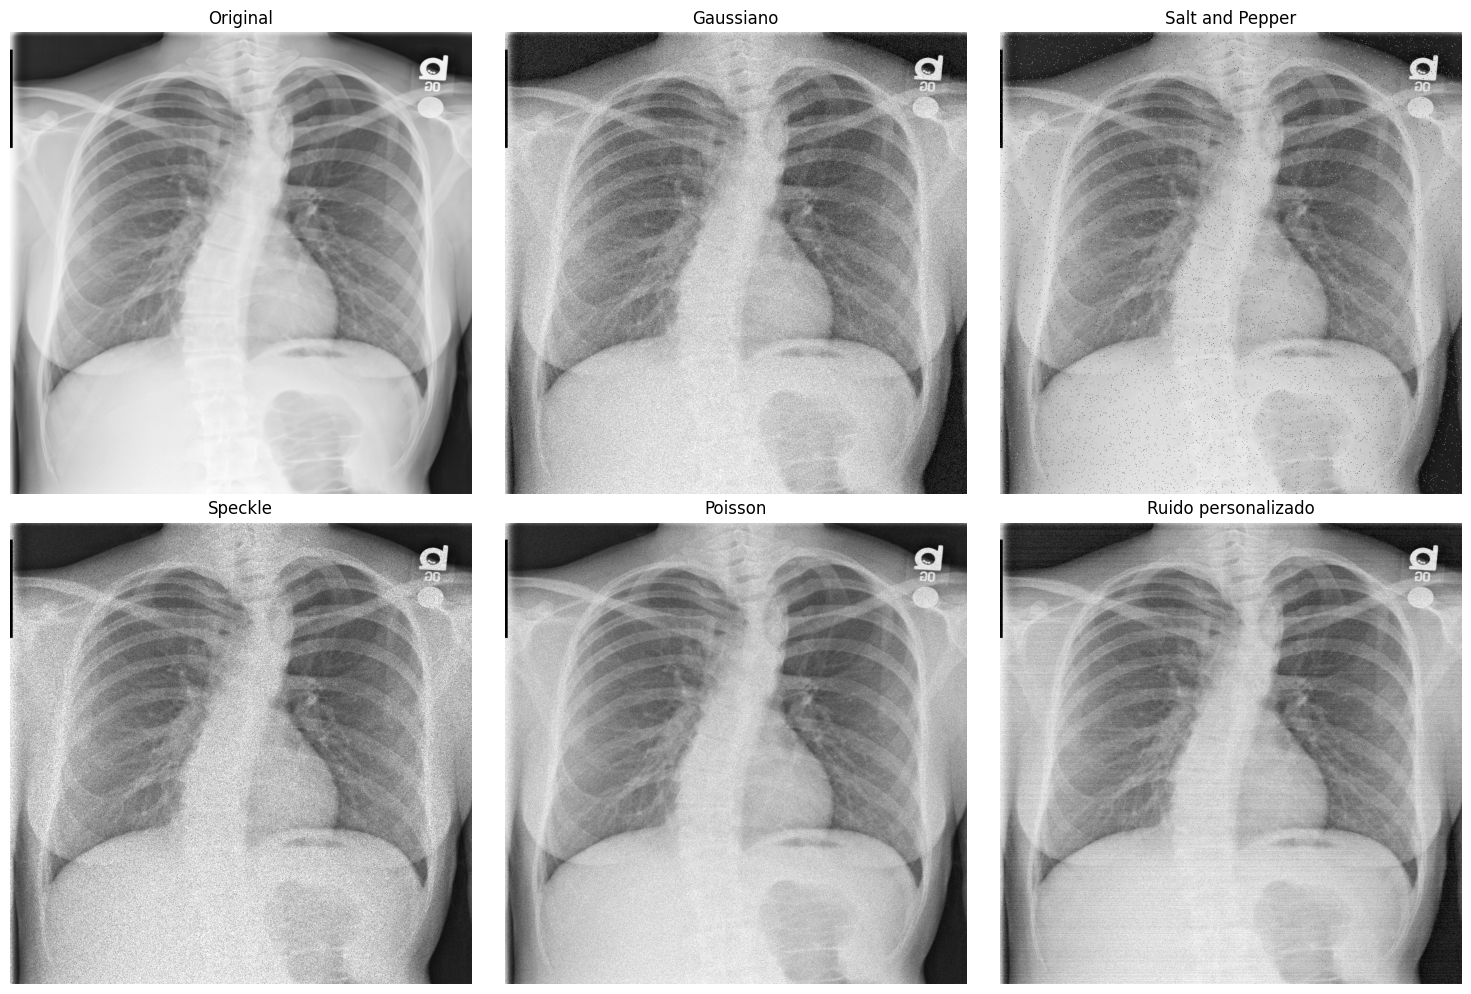

In [ ]:
plt.figure(figsize=(15,10))
plt.subplot(2,3,1)

plt.imshow(imagen_gris, cmap='gray')

plt.title("Original")

plt.axis('off')

plt.subplot(2,3,2)

plt.imshow(imagen_gaussiana, cmap='gray')

plt.title("Gaussiano")

plt.axis('off')

plt.subplot(2,3,3)

plt.imshow(imagen_sal_pimienta, cmap='gray')

plt.title("Salt and Pepper")

plt.axis('off')

plt.subplot(2,3,4)

plt.imshow(imagen_speckle, cmap='gray')

plt.title("Speckle")

plt.axis('off')

plt.subplot(2,3,5)

plt.imshow(imagen_poissonn, cmap='gray')

plt.title("Poisson")

plt.axis('off')

plt.subplot(2,3,6)

plt.imshow(imagen_interferencia, cmap='gray')

plt.title("Ruido personalizado")

plt.axis('off')

plt.tight_layout()

plt.show()

# Guardar y descargar imágenes

In [ ]:
#plt.imsave("imagen_gaussiana.png", imagen_gaussiana, cmap='gray')

#plt.imsave("imagen_sal_pimienta.png", imagen_sal_pimienta, cmap='gray')

#plt.imsave("imagen_speckle.png", imagen_speckle, cmap='gray')

#plt.imsave("imagen_poissonn.png", imagen_poissonn, cmap='gray')

#plt.imsave("imagen_interferencia.png", imagen_interferencia, cmap='gray')

In [ ]:
#from google.colab import files

#files.download("imagen_gaussiana.png")
#files.download("imagen_sal_pimienta.png")
#files.download("imagen_speckle.png")
#files.download("imagen_poissonn.png")
#files.download("imagen_interferencia.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>